## Conditional Graph
Objectives: <br/>
1. Implement Conditional logic to route the flow of data to different nodes
2. use START and END nodes to manage entry & exit points explictly 
3. Design multiple nodes to perform different operations (additions, subtraction)
4. Create a router node to handle decision-making and control graph flow

Main Goal: How to use "add_conditional_edges()"

In [1]:
from typing import TypedDict
from langgraph.graph import StateGraph, START, END

In [2]:
class AgentState(TypedDict):
    number1: int
    operation: str
    number2: int
    finalNumber: int

In [3]:
def adder(state: AgentState) -> AgentState:
    """This node adds the 2 numbers"""

    state["finalNumber"] = state["number1"] + state["number2"]
    return state

def subtractor(state: AgentState) -> AgentState:
    """ This node subtracts the 2 numbers """

    state["finalNumber"] = state["number1"] - state["number2"]
    return state

def decide_next_node(state: AgentState) -> AgentState:
    """ This node will select the next node of the graph """

    if state["operation"] == "+":
        # return the edge name 
        return "addition_operation"
    
    elif state["operation"] == "-":
        return "subtraction_operation"
    
    

In [4]:
graph = StateGraph(AgentState)

graph.add_node("add_node", adder)
graph.add_node("substract_node", subtractor)

## if it returns the edge, then we do this: input state = output state
graph.add_node("router", lambda state: state) # passthrough function

graph.add_edge(START, "router")

graph.add_conditional_edges(
    "router",
    decide_next_node,

    {
        # Edge format: Node
        "addition_operation": "add_node",
        "subtraction_operation": "substract_node"
    }
)

graph.add_edge("add_node", END)
graph.add_edge("substract_node", END)

app = graph.compile()



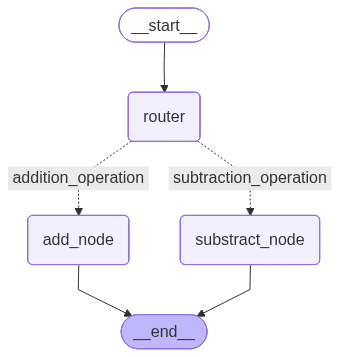

In [5]:
from IPython.display import display, Image
display(Image(app.get_graph().draw_mermaid_png()))

In [7]:
initial_state_1 = AgentState(number1 = 10, operation= "-", number2 = 5)
print(app.invoke(initial_state_1))

initial_state_2 = AgentState(number1 = 10, operation= "+", number2 = 5)
print(app.invoke(initial_state_2))

{'number1': 10, 'operation': '-', 'number2': 5, 'finalNumber': 5}
{'number1': 10, 'operation': '+', 'number2': 5, 'finalNumber': 15}
